In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import os
import re
import xarray as xr
from read_CT import*
from socket import gethostname

%load_ext autoreload
%autoreload 2
%matplotlib inline
    
import os
os.chdir("../../..")
savedir = os.path.join(os.getcwd(),"DATA")
path = os.getcwd()
path_adcp = os.path.join(path,"DATA/SIOS21/adcp_data_and_analysis_lars_smedsrud/")
ds_adcp = xr.open_dataset(path_adcp+"Nortek_ADCP_currents_Oct20_to_Nov4_avgd_cal.nc", engine="netcdf4")

In [3]:
path_CT = os.path.join(path,"DATA/SIOS21/Ant2021/Ant2021CT/", "CT_data_small.nc")
if os.path.exists(path_CT):
    ds = xr.open_dataset(path_CT, engine='netcdf4')
else:
    print("reading CNV files")
    ds = read_write_all_cnv(os.path.join(path_CT))

In [5]:
# downsample to ADCP temporal resolution for easier checking signs
ds = ds.resample(time="10min").mean()

In [6]:
# calculate freezing point temperature
from seawater import eos80
fp = eos80.fp(ds.Salinity_PSU, 3.55) # converted to ITS-90
ds["fp"] = (["time"], fp)

/tmp/ipykernel_56343/857175643.py:2: UserWarning: The seawater library is deprecated! Please use gsw instead.
  from seawater import eos80


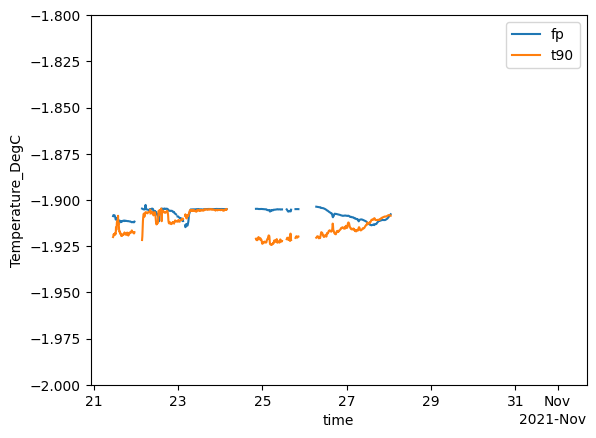

In [7]:
plt.figure()
ds.fp.plot(label="fp")
ds.Temperature_DegC.plot(label="t90")
plt.ylim([-2,-1.8])
plt.legend()

In [8]:
from scipy.interpolate import interp1d
# convert array of datetime64 to integers for interpolation
time_int = ds.time.data.astype("int")
# redefine time_adcp for end date CT
time_adcp = ds_adcp.time[ds_adcp.time<ds.time[-1]]
# convert to integer
time_adcp_int = time_adcp.astype("int")

In [9]:
# interpolate CT data
f_CT_T = interp1d(time_int, ds.Temperature_DegC)
f_CT_S = interp1d(time_int, ds.Salinity_PSU)
f_CT_C = interp1d(time_int, ds.Conductivity_S_m)
# choose only ADCP time stamps where there is CT data
print("start adcp: ", ds_adcp.time[0].data)
print("end adcp: ", ds_adcp.time[-1].data)
print("start CT: ", ds.time[0].data)
print("end CT: ", ds.time[-1].data)
# evaluate CT data on ADCP coordinates
# check if the end time of ADCP is before the end time CT
# also check if the start time adcp after start time CT
if ((time_adcp[-1].data<ds.time[-1].data) and (time_adcp[0]>ds.time[0])):
    Tnew = f_CT_T(time_adcp_int)
    Snew = f_CT_S(time_adcp_int)
    Cnew = f_CT_C(time_adcp_int)
# remove interpolations where there is no data
# detect the jumps in Time_System_s
timeS_rel = ds.Time_System_s.data - ds.Time_System_s[0].data
time_diff = timeS_rel[1:]-timeS_rel[0:-1]
# find time of jump
# 6000 is chosen as a threshold, such that the amount of times the instrument was out of the water is 6
# wrongful interpolation during other times is not considered
start = ds.time[np.where(time_diff>6000)[0]].data
stop = ds.time[np.where(time_diff>6000)[0]+1].data
# fill in NaN where there is no data
for i in range(len(start)):
    Tnew[(time_adcp>start[i])&(time_adcp<stop[i])] = np.nan
    Snew[(time_adcp>start[i])&(time_adcp<stop[i])] = np.nan
    Cnew[(time_adcp>start[i])&(time_adcp<stop[i])] = np.nan

start adcp:  2021-10-21T11:01:18.062991000
end adcp:  2021-11-05T05:12:51.062994000
start CT:  2021-10-21T11:00:00.000000000
end CT:  2021-11-01T03:40:00.000000000


AttributeError: 'Dataset' object has no attribute 'Time_System_s'

In [10]:
# FIX-ME: somehow the supercooling has changed since attempt to tidy up on 12/2/2026
# calculate freezing point temperature for resampled data
fp = eos80.fp(Snew, 3.55) # converted to ITS-90
sc = abs(Tnew) - abs(fp)

In [11]:
ds_adcp

<xarray.Dataset> Size: 1MB
Dimensions:           (depth_profile: 20, time: 2131)
Coordinates:
  * depth_profile     (depth_profile) float64 160B 4.573 5.573 ... 22.57 23.57
  * time              (time) datetime64[ns] 17kB 2021-10-21T11:01:18.062991 ....
    u                 (time) float64 17kB ...
    v                 (time) float64 17kB ...
    w                 (time) float64 17kB ...
    temperature       (time) float64 17kB ...
    tide_z            (time) float64 17kB ...
    tide_u            (time) float64 17kB ...
    tide_v            (time) float64 17kB ...
Data variables:
    depth_bins        (depth_profile, time) float64 341kB ...
    amplitude         (depth_profile, time) float64 341kB ...
    instrument_depth  (time) float64 17kB ...
    BSv               (depth_profile, time) float64 341kB ...

In [39]:
ds_new = xr.Dataset(
                    data_vars = dict(Temperature_DegC = (["time"], Tnew),
                                   Salinity_PSU = (["time"], Snew),
                                    Depth_m = (["time"], np.full(time_adcp.shape, ds.Depth_m[0].data)),
                                    fp = (["time"], fp),
                                    SC = (["time"], sc*1e3),
                                    Pressure_db = (["time"], np.full(time_adcp.shape, ds.Pressure_db[0].data)),
                                    Conductivity_S_m = (["time"], Cnew)),
                   coords = dict(time = ("time", time_adcp.data)))
if os.path.exists(path+"Ant2021/Ant2021CT/CT_data_small.nc"):
    os.remove(path+"Ant2021/Ant2021CT/CT_data_small.nc")
ds_new.to_netcdf(path+"Ant2021/Ant2021CT/CT_data_small.nc", engine="netcdf4")

In [28]:
path+"CT_data_small.nc"

'/home/nina/pCloudDrive/DATA/SIOS18/CT_data_small.nc'

(-1.93, -1.9)

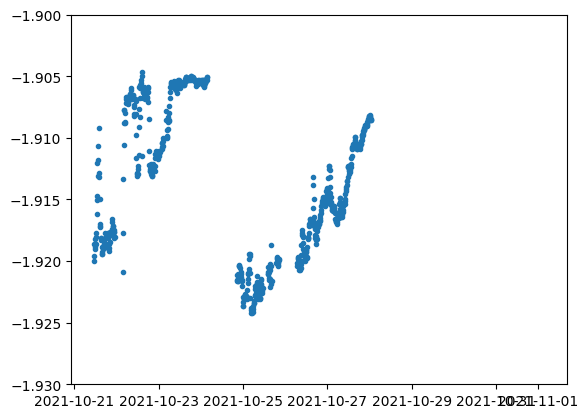

In [12]:
fig, ax = plt.subplots()
ax.plot(time_adcp, Tnew, ".")
ax.set_ylim([-1.93, -1.9])
# FIXME: why are "no data" points interpolated?

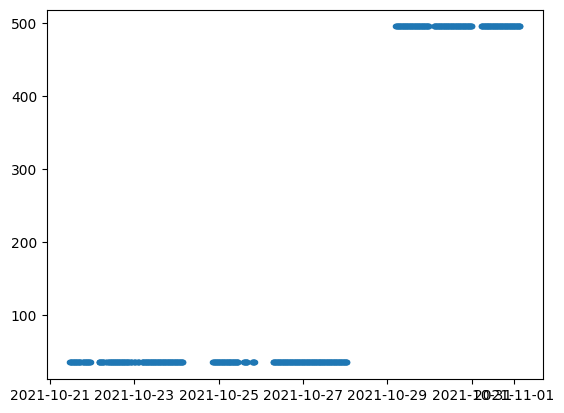

In [13]:
fig, ax = plt.subplots()
ax.plot(time_adcp, Snew, ".")


(-1.93, -1.9)

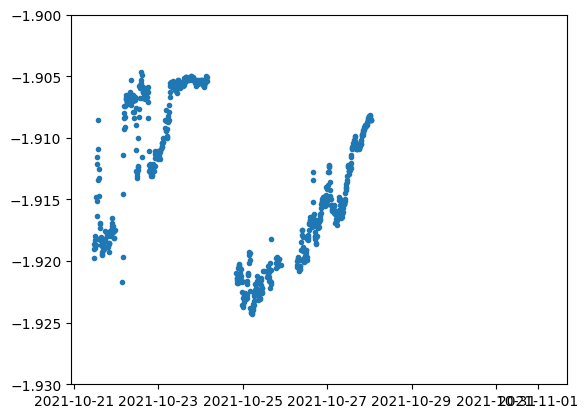

In [14]:
fig, ax = plt.subplots()
ax.plot(ds.time[ds.time>ds_adcp.time[0]], ds.Temperature_DegC[ds.time>ds_adcp.time[0]], ".")
ax.set_ylim([-1.93, -1.9])